# 07a — Results: did replay work?

Every completed run, all orders and seeds, scored on the **validation** sets. Read it top to bottom:

1. **Ranking** — every method on retention, final-task learning and the final three-behavior average.
2. **Where the differences come from** — per behavior, per order–seed cell, with paired uncertainty.
3. **Cost** and the **LoRA-EWC coefficient** choice.

*Why* methods differ (one example run, which pairs were replayed, anchor and gate diagnostics) is in `07b_mechanisms.ipynb`. Only CARC results are used; the old Colab study is in `notebooks/colab/`.

## 1. The six task orders

One model learns three behaviors in sequence.

| Order | Stage 1 | Stage 2 | Stage 3 |
|---|---|---|---|
| **Order 1** | Helpful | Safe | Quality |
| **Order 2** | Safe | Helpful | Quality |
| **Order 3** | Quality | Helpful | Safe |
| **Order 4** | Quality | Safe | Helpful |
| **Order 5** | Helpful | Quality | Safe |
| **Order 6** | Safe | Quality | Helpful |

Orders 1–4 × seeds 0–1 are the development cells used to choose methods. Orders 5–6 and seeds 2–4 are the confirmation cells (see `docs/FREEZE.md`). Tables include whatever runs have finished. The behavior trained last in an order cannot be forgotten, so each order measures forgetting of its first two behaviors only.


## 2. What accuracy means

Each validation example has a prompt, a preferred answer, and a rejected answer. A pair counts as correct when training moved the model toward the preferred answer relative to the frozen base model.

- Higher accuracy is better.
- This is preference accuracy, not proof that generated answers are truly safe, helpful, or correct.


## 3. Setup

`FOCUS_ORDER` and `FOCUS_SEED` control only the early step-by-step example. You do not need to change them to see the complete study: the full-grid dashboard near the end always includes all four orders and both seeds. Run the notebook once from top to bottom. Tables are normal HTML, not the large interactive viewer, so they are easier to select and copy.

Set `SAVE_OUTPUTS = True` only when you want CSV tables and PNG figures saved under the CARC artifact directory.


In [ ]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

FOCUS_ORDER = 1 # change to see other results
FOCUS_SEED = 0 # change to see other results

SAVE_OUTPUTS = False
os.environ["MFR_OUTPUT_DIR"] = "/project2/xiangren_1987/grp26-mfr-dpo/artifacts"
REPO = next((p for p in [Path.cwd(), Path.cwd().parent]
             if (p/'configs/experiment_protocol.json').exists()), None)
if REPO is None:
    raise FileNotFoundError('Open this notebook from the mfr-dpo repository')
if 'MFR_OUTPUT_DIR' not in os.environ:
    raise EnvironmentError('Set MFR_OUTPUT_DIR to the absolute CARC artifact directory first')
ARTIFACT_DIR = Path(os.environ['MFR_OUTPUT_DIR']).expanduser().resolve()

protocol = json.loads((REPO/'configs/experiment_protocol.json').read_text())
TOLERANCE = protocol['new_learning_tolerance_points']
OUTPUT_DIR = ARTIFACT_DIR/'analysis/notebook_07'
METHODS = protocol['methods'] + protocol['secondary_methods']
MLABEL = {'none':'No replay','random':'Random 10%','random_high':'Random 14.3%',
          'lowest_margin':'Lowest margin','mfr':'MFR 10%','fmcr':'FMCR 10%',
          'cpmr':'CPMR 10%', 'dapr':'DAPR-Strong 10%',
          'dapr_weak':'DAPR (α=0.01)', 'dapr_gated':'DAPR-Gated (α=0.1)',
          'dapr_c':'DAPR-C 10%', 'mir_dpo':'MIR-DPO 10%',
          'copr_adapted':'COPR-adapted 10%', 'ewc_100':'LoRA-EWC (λ=100)',
          'ewc_1000':'LoRA-EWC (λ=1,000)', 'ewc_10000':'LoRA-EWC (λ=10,000)',
          'mfr_balanced':'Balanced MFR 10%', 'mfr_at_risk':'At-Risk MFR 10%'}
MCOLOR = {'none':'#666666','random':'#377bd1','random_high':'#7557c7',
          'lowest_margin':'#20a878','mfr':'#ef6a32','fmcr':'#b52fb5',
          'cpmr':'#7a3db8', 'dapr':'#d68a00', 'dapr_weak':'#e6ad38',
          'dapr_gated':'#8a5a00', 'dapr_c':'#a45c00',
          'mir_dpo':'#008c95', 'copr_adapted':'#b13c63',
          'ewc_100':'#4c78a8', 'ewc_1000':'#355f8a', 'ewc_10000':'#1f3b57',
         'mfr_balanced':'#c0392b', 'mfr_at_risk':'#7b241c'}
for i,method in enumerate(METHODS):
    MLABEL.setdefault(method, method.replace('_',' ').title())
    MCOLOR.setdefault(method, plt.get_cmap('tab10')(i % 10))
DATASETS = ['helpful','safe','quality']
DLABEL = {'helpful':'Helpful','safe':'Safe','quality':'Quality'}
DCOLOR = {'helpful':'#377bd1','safe':'#d14b61','quality':'#20a878'}

def show_table(df, name):
    out=df.copy()
    out.columns.name=None
    out.index.name=None
    nums=out.select_dtypes(include='number').columns
    out[nums]=out[nums].round(2)
    display(HTML(out.to_html(index=False,border=0,na_rep='—',classes='result-table')))
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
        out.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)

def finish(fig,name):
    # Some multi-panel figures already use constrained_layout. Switching them to
    # tight_layout after adding a colorbar raises an error in newer Matplotlib versions.
    if fig.get_layout_engine() is None:
        fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
        fig.savefig(OUTPUT_DIR/f'{name}.png',dpi=200,bbox_inches='tight')
    plt.show()

plt.rcParams.update({'figure.dpi':105,'font.size':9,'axes.spines.top':False,'axes.spines.right':False})
display(HTML('''<style>
.result-table{border-collapse:collapse;font-size:13px;margin:8px 0 16px}
.result-table th{
    background:#333333;
    color:#ffffff;
    font-weight:600;
}
.result-table th,.result-table td{border:1px solid #bbb;padding:5px 9px;text-align:center}
</style>'''))
print('Reading:', ARTIFACT_DIR/'runs')


Reading: /project2/xiangren_1987/grp26-mfr-dpo/artifacts/runs


## 4. Load the completed runs

Only run folders containing `COMPLETE.json`, `settings.json`, and `results.csv` are used. Pilot runs are ignored. This first small table shows what is available.


In [ ]:
frames=[]; records={}
for folder in sorted((ARTIFACT_DIR/'runs').glob('*')):
    needed=[folder/'COMPLETE.json',folder/'settings.json',folder/'results.csv']
    if not all(p.exists() for p in needed): continue
    s=json.loads((folder/'settings.json').read_text())
    if str(s.get('protocol_version'))!=str(protocol['protocol_version']): continue
    if str(s.get('method')) not in METHODS: continue  # ignore superseded diagnostic methods
    r={'run_name':s.get('run_name',folder.name),'order_id':int(s['order_id']),
       'order':list(s['order']),'method':str(s['method']),'seed':int(s['seed']),
       'folder':folder,'stage1_from':s.get('stage1_from')}
    records[r['run_name']]=r
    f=pd.read_csv(folder/'results.csv')
    for key in ['run_name','order_id','method','seed']: f[key]=r[key]
    frames.append(f)
if not frames: raise FileNotFoundError('No completed v2 runs were found')
runs=pd.concat(frames,ignore_index=True)
METHODS=[method for method in METHODS if method in set(runs.method)]

inventory=pd.DataFrame([{'Order':r['order_id'],'Sequence':' → '.join(DLABEL[x] for x in r['order']),
                         'Seed':r['seed'],'Method':MLABEL[r['method']]} for r in records.values()])
show_table(inventory.sort_values(['Order','Seed','Method']),'completed_runs')


In [ ]:
def stage_folder(r,stage):
    d=r['order'][stage-1]; direct=r['folder']/f'stage{stage}_{d}'
    if direct.exists(): return direct
    if stage==1 and r['stage1_from']:
        source=Path(r['stage1_from'])
        if not source.exists(): source=r['folder'].parent/source.name
        return source/f'stage1_{d}'
    return direct


## 5. One summary row per run

For each run: mean change of the two earlier behaviors (retention), the final-task score, and the final average of all three behaviors.

In [ ]:
summary=[]
for name,r in records.items():
    p=runs[runs.run_name==name]; changes=[]
    for stage,d in enumerate(r['order'][:-1],1):
        a=p[(p.stage==stage)&(p.eval_set==d)]; z=p[(p.stage==len(r['order']))&(p.eval_set==d)]
        if len(a) and len(z): changes.append(float(z.iloc[0].accuracy-a.iloc[0].accuracy))
    z=p[p.stage==len(r['order'])]; task=z[z.eval_set==r['order'][-1]]
    if len(changes)==2 and len(task):
        summary.append({'run_name':name,'order_id':r['order_id'],'seed':r['seed'],'method':r['method'],
                        'old_change':np.mean(changes),'final_task':float(task.iloc[0].accuracy),
                        'final_average':z.accuracy.mean()})
summary=pd.DataFrame(summary)


## 6. Ranking of all methods

This table updates automatically whenever another method has all of its completed run folders. It combines every available order and seed and is ordered from most forgetting to least forgetting. Higher old-behavior change is better because it means less forgetting. The percentage column divides the retention gain by the amount forgotten with No Replay.


In [ ]:
grid=(summary.groupby('method').agg(Cells=('run_name','size'),
    **{'Average old-behavior change':('old_change','mean'),
       'Final-task accuracy':('final_task','mean'),'Final three-behavior average':('final_average','mean')})
    .reindex(METHODS).dropna(how='all'))
no_old=grid.loc['none','Average old-behavior change']; no_final=grid.loc['none','Final three-behavior average']
grid['Retention gain vs no replay']=grid['Average old-behavior change']-no_old
grid['Forgetting prevented (%)']=100*grid['Retention gain vs no replay']/abs(no_old)
grid['Final-average gain vs no replay']=grid['Final three-behavior average']-no_final
ranking=grid.reset_index().rename(columns={'method':'Method'}).sort_values(
    ['Average old-behavior change','Final three-behavior average'],ascending=True)
ranking.Method=ranking.Method.map(MLABEL)
show_table(ranking.round(2),'current_complete_grid_ranking')

comparisons=[]
for method in METHODS:
    if method in {'none','random'} or method not in set(summary.method): continue
    paired=summary[summary.method==method].merge(summary[summary.method=='random'],
        on=['order_id','seed'],suffixes=('_method','_random'))
    if paired.empty: continue
    retention=paired.old_change_method-paired.old_change_random
    task=paired.final_task_method-paired.final_task_random
    comparisons.append({'Method':MLABEL[method],'Matched cells':len(paired),
        'Retention advantage vs Random':retention.mean(),
        'Final-task difference vs Random':task.mean(),
        'Cells passing frozen rule':int(((retention>0)&(task>=-TOLERANCE)).sum())})
show_table(pd.DataFrame(comparisons).round(2),'all_methods_vs_random')

retention_leader=grid['Average old-behavior change'].idxmax()
balance_leader=grid['Final three-behavior average'].idxmax()
print(f"Least forgetting: {MLABEL[retention_leader]} "
      f"({grid.loc[retention_leader,'Average old-behavior change']:.2f} points).")
print(f"Highest final three-behavior average: {MLABEL[balance_leader]} "
      f"({grid.loc[balance_leader,'Final three-behavior average']:.2f}%).")
if {'cpmr','random','lowest_margin'}<=set(grid.index):
    print(f"CPMR versus Random 10%: "
          f"{grid.loc['cpmr','Average old-behavior change']-grid.loc['random','Average old-behavior change']:+.2f} "
          f"retention points and "
          f"{grid.loc['cpmr','Final three-behavior average']-grid.loc['random','Final three-behavior average']:+.2f} "
          f"final-average points.")
    print(f"CPMR versus Lowest Margin: "
          f"{grid.loc['cpmr','Average old-behavior change']-grid.loc['lowest_margin','Average old-behavior change']:+.2f} "
          f"retention points and "
          f"{grid.loc['cpmr','Final three-behavior average']-grid.loc['lowest_margin','Final three-behavior average']:+.2f} "
          f"final-average points.")
if {'dapr_weak','random','lowest_margin'}<=set(grid.index):
    print(f"DAPR (α=0.01) versus Random 10%: "
          f"{grid.loc['dapr_weak','Average old-behavior change']-grid.loc['random','Average old-behavior change']:+.2f} "
          f"retention points and "
          f"{grid.loc['dapr_weak','Final three-behavior average']-grid.loc['random','Final three-behavior average']:+.2f} "
          f"final-average points.")
    print(f"DAPR (α=0.01) versus Lowest Margin: "
          f"{grid.loc['dapr_weak','Average old-behavior change']-grid.loc['lowest_margin','Average old-behavior change']:+.2f} "
          f"retention points and "
          f"{grid.loc['dapr_weak','Final three-behavior average']-grid.loc['lowest_margin','Final three-behavior average']:+.2f} "
          f"final-average points.")


Method,Cells,Average old-behavior change,Final-task accuracy,Final three-behavior average,Retention gain vs no replay,Forgetting prevented (%),Final-average gain vs no replay
DAPR-C 10%,8,0.81,69.56,72.77,8.75,110.24,2.00
DAPR-Strong 10%,8,0.34,70.75,72.88,8.28,104.33,2.10
DAPR-Gated (α=0.1),8,-0.16,71.62,73.21,7.78,98.03,2.44
COPR-adapted 10%,8,-0.94,60.56,65.75,7.00,88.19,-5.02
DAPR (α=0.01),8,-1.94,72.81,73.44,6.00,75.59,2.67
CPMR 10%,8,-4.28,74.56,72.85,3.66,46.06,2.08
Lowest margin,8,-4.47,74.31,72.56,3.47,43.70,1.79
MIR-DPO 10%,8,-4.72,73.81,72.08,3.22,40.55,1.31
MFR 10%,8,-4.88,73.75,71.98,3.06,38.58,1.21
FMCR 10%,8,-5.44,74.75,72.21,2.50,31.50,1.44


Method,Matched cells,Retention advantage vs Random,Final-task difference vs Random,Cells passing frozen rule
MFR 10%,8,0.62,0.12,7
Random 14.3%,8,0.03,0.25,4
Lowest margin,8,1.03,0.69,7
FMCR 10%,8,0.06,1.12,4
CPMR 10%,8,1.22,0.94,6
DAPR-Strong 10%,8,5.84,-2.88,3
DAPR (α=0.01),8,3.56,-0.81,6
DAPR-Gated (α=0.1),8,5.34,-2.00,4
DAPR-C 10%,8,6.31,-4.06,2
MIR-DPO 10%,8,0.78,0.19,6


Least forgetting: DAPR-C 10% (0.81 points).
Highest final three-behavior average: DAPR (α=0.01) (73.44%).
CPMR versus Random 10%: +1.22 retention points and +1.15 final-average points.
CPMR versus Lowest Margin: +0.19 retention points and +0.29 final-average points.
DAPR (α=0.01) versus Random 10%: +3.56 retention points and +1.73 final-average points.
DAPR (α=0.01) versus Lowest Margin: +2.53 retention points and +0.88 final-average points.


## 7. Averages over all cells

Every completed run is included below. The tables update automatically as new methods finish. Orders 3 and 4 make Quality an earlier behavior, so Quality forgetting is measurable there. The final behavior in any individual order still has no forgetting measurement because no training happens after it.


In [ ]:
overall=(summary.groupby('method').agg(**{'Cells completed':('run_name','count'),
  'Average old-behavior change':('old_change','mean'),'Average final-task score':('final_task','mean'),
  'Average final score across all 3':('final_average','mean')}).reindex(METHODS).dropna(how='all').reset_index().rename(columns={'method':'Method'}))
overall=overall.sort_values(['Average old-behavior change','Average final score across all 3'])
overall.Method=overall.Method.map(MLABEL); show_table(overall,'all_completed_cells')


Method,Cells completed,Average old-behavior change,Average final-task score,Average final score across all 3
No replay,8,-7.94,74.81,70.77
Random 10%,8,-5.50,73.62,71.71
MFR 10%,8,-4.88,73.75,71.98
Random 14.3%,8,-5.47,73.88,71.73
Lowest margin,8,-4.47,74.31,72.56
FMCR 10%,8,-5.44,74.75,72.21
CPMR 10%,8,-4.28,74.56,72.85
DAPR-Strong 10%,8,0.34,70.75,72.88
DAPR (α=0.01),8,-1.94,72.81,73.44
DAPR-Gated (α=0.1),8,-0.16,71.62,73.21


### Forgetting by behavior

This combines every order in which a dataset was followed by later training. Helpful and Safe are measurable in six order–seed cells per method. Quality is measurable in four cells per method because it is first in Orders 3 and 4. Closer to zero is better.


Method,Helpful change (n=6),Safe change (n=6),Quality change (n=4)
No replay,-6.25,-13.25,-2.50
Random 10%,-4.50,-8.75,-2.12
MFR 10%,-4.83,-7.33,-1.25
Random 14.3%,-5.00,-8.08,-2.25
Lowest margin,-4.42,-6.67,-1.25
FMCR 10%,-4.17,-8.58,-2.62
CPMR 10%,-3.92,-7.00,-0.75
DAPR-Strong 10%,-0.50,0.67,1.12
DAPR (α=0.01),-3.58,-1.50,-0.12
DAPR-Gated (α=0.1),-0.33,-1.00,1.38


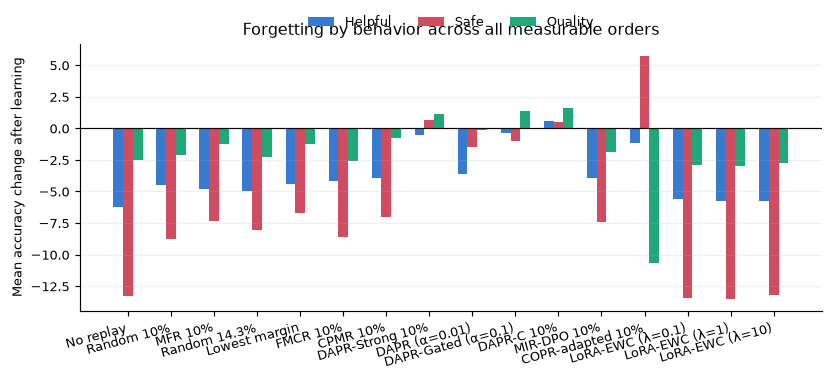

In [ ]:
all_retention=[]
for name,r in records.items():
    part=runs[runs.run_name==name]
    for learned_stage,dataset in enumerate(r['order'][:-1],1):
        learned=part[(part.stage==learned_stage)&(part.eval_set==dataset)]
        final=part[(part.stage==len(r['order']))&(part.eval_set==dataset)]
        if len(learned) and len(final):
            all_retention.append({'order_id':r['order_id'],'seed':r['seed'],
                'method':r['method'],'dataset':dataset,
                'change':float(final.iloc[0].accuracy-learned.iloc[0].accuracy)})
all_retention=pd.DataFrame(all_retention)

means=(all_retention.groupby(['method','dataset']).change.mean()
       .unstack().reindex(METHODS).reindex(columns=DATASETS))
counts=(all_retention.groupby(['method','dataset']).size()
        .unstack().reindex(METHODS).reindex(columns=DATASETS))
dataset_table=means.reset_index().rename(columns={'method':'Method'})
dataset_table.Method=dataset_table.Method.map(MLABEL)
dataset_table=dataset_table.rename(columns={
    d:f'{DLABEL[d]} change (n={int(counts[d].max())})' for d in DATASETS})
show_table(dataset_table,'full_grid_forgetting_by_dataset')

fig,ax=plt.subplots(figsize=(8,3.7))
x=np.arange(len(METHODS)); width=.23
for i,d in enumerate(DATASETS):
    ax.bar(x+(i-1)*width,means[d],width,label=DLABEL[d],color=DCOLOR[d])
ax.axhline(0,color='black',lw=.8); ax.grid(axis='y',alpha=.2)
ax.set_xticks(x,[MLABEL[m] for m in METHODS],rotation=15,ha='right')
ax.set_ylabel('Mean accuracy change after learning')
ax.set_title('Forgetting by behavior across all measurable orders')
ax.legend(ncol=3,frameon=False,loc='lower center',bbox_to_anchor=(.5,1.01))
finish(fig,'07_full_grid_forgetting_by_dataset')


### Every order–seed cell

The first table reports mean forgetting across the two earlier behaviors. The second reports the final average across Helpful, Safe, and Quality. Each row is one complete comparison cell and every method is shown.


Order,Sequence,Seed,No replay,Random 10%,MFR 10%,Random 14.3%,Lowest margin,FMCR 10%,CPMR 10%,DAPR-Strong 10%,DAPR (α=0.01),DAPR-Gated (α=0.1),DAPR-C 10%,MIR-DPO 10%,COPR-adapted 10%,LoRA-EWC (λ=0.1),LoRA-EWC (λ=1),LoRA-EWC (λ=10)
1,Helpful → Safe → Quality,0,-9.00,-6.75,-5.75,-6.00,-5.50,-6.00,-6.75,-1.50,-3.25,-1.25,-0.50,-4.50,3.50,-8.75,-9.25,-9.00
1,Helpful → Safe → Quality,1,-10.50,-5.50,-5.00,-5.50,-4.75,-5.50,-5.75,2.25,-1.75,0.75,1.75,-5.50,2.50,-10.50,-10.25,-10.75
2,Safe → Helpful → Quality,0,-12.50,-10.00,-9.00,-9.25,-8.50,-9.25,-7.75,-0.50,-4.00,-1.75,0.50,-8.50,-1.25,-12.25,-11.75,-12.25
2,Safe → Helpful → Quality,1,-13.50,-9.75,-9.50,-9.50,-8.50,-8.25,-6.75,-0.50,-2.75,-2.00,-0.50,-9.25,-2.00,-13.00,-13.00,-12.75
3,Quality → Helpful → Safe,0,-4.00,-1.25,-1.00,-2.75,0.50,-2.25,-0.25,0.75,-0.75,2.00,1.00,-0.50,-5.75,-4.00,-4.25,-3.75
3,Quality → Helpful → Safe,1,-4.75,-2.25,-2.00,-3.00,-3.00,-4.00,-1.75,-0.25,-1.25,1.00,2.25,-3.00,-7.25,-4.00,-4.75,-3.75
4,Quality → Safe → Helpful,0,-3.75,-3.25,-3.50,-3.25,-1.50,-3.00,-2.00,1.00,0.00,-0.25,0.00,-2.50,1.50,-4.50,-4.25,-4.25
4,Quality → Safe → Helpful,1,-5.50,-5.25,-3.25,-4.50,-4.50,-5.25,-3.25,1.50,-1.75,0.25,2.00,-4.00,1.25,-5.75,-6.25,-5.75


Order,Sequence,Seed,No replay,Random 10%,MFR 10%,Random 14.3%,Lowest margin,FMCR 10%,CPMR 10%,DAPR-Strong 10%,DAPR (α=0.01),DAPR-Gated (α=0.1),DAPR-C 10%,MIR-DPO 10%,COPR-adapted 10%,LoRA-EWC (λ=0.1),LoRA-EWC (λ=1),LoRA-EWC (λ=10)
1,Helpful → Safe → Quality,0,70.33,71.33,72.00,71.50,72.17,72.17,71.83,71.83,72.67,72.50,72.33,72.33,67.00,70.67,70.83,70.83
1,Helpful → Safe → Quality,1,69.50,72.33,72.50,72.33,72.67,72.33,72.33,75.00,74.33,74.50,74.17,72.17,67.33,70.00,69.67,69.33
2,Safe → Helpful → Quality,0,69.17,70.67,71.17,70.67,72.00,70.83,72.17,75.00,72.50,73.50,74.83,70.67,65.00,68.83,69.33,69.33
2,Safe → Helpful → Quality,1,67.67,69.67,70.00,69.50,71.00,70.50,71.50,74.50,75.33,74.00,74.33,70.50,64.00,67.83,67.67,67.83
3,Quality → Helpful → Safe,0,73.17,73.33,73.33,72.83,73.83,73.67,74.33,71.33,73.00,72.83,70.83,73.17,65.33,72.50,72.83,73.00
3,Quality → Helpful → Safe,1,72.17,72.83,72.67,72.50,73.17,72.83,74.17,71.67,73.33,73.17,72.67,73.50,64.83,72.83,72.17,72.83
4,Quality → Safe → Helpful,0,72.50,72.67,72.17,72.17,74.00,73.33,73.67,71.83,73.00,72.50,71.33,72.50,66.67,71.83,72.17,72.17
4,Quality → Safe → Helpful,1,71.67,70.83,72.00,72.33,71.67,72.00,72.83,71.83,73.33,72.67,71.67,71.83,65.83,71.33,71.50,71.67


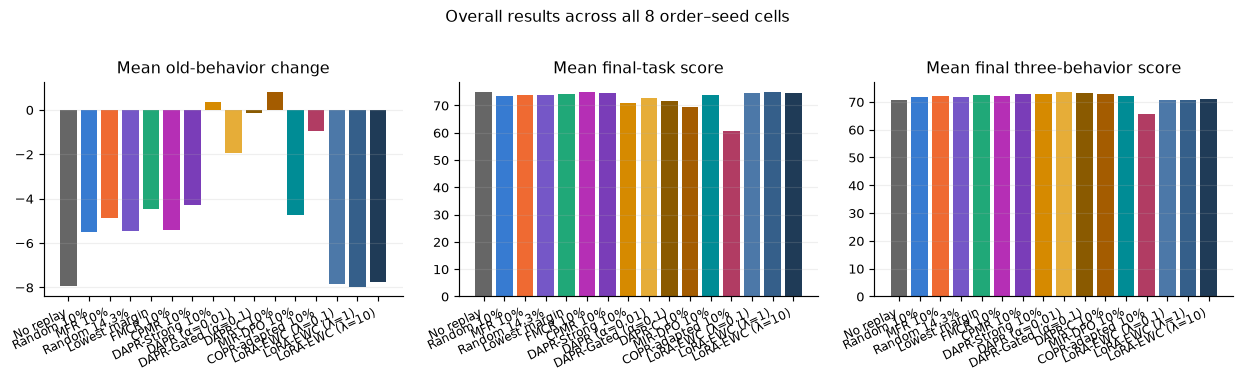

In [ ]:
def all_cell_table(metric):
    table=(summary.pivot(index=['order_id','seed'],columns='method',values=metric)
           .reindex(columns=METHODS).reset_index())
    table.insert(1,'Sequence',table.order_id.map(
        lambda value:' → '.join(DLABEL[d] for d in protocol['orders'][str(value)])))
    return table.rename(columns={'order_id':'Order','seed':'Seed',
                                 **{m:MLABEL[m] for m in METHODS}})

show_table(all_cell_table('old_change'),'full_grid_each_cell_forgetting')
show_table(all_cell_table('final_average'),'full_grid_each_cell_final_average')

aggregate=summary.groupby('method').agg(
    retention=('old_change','mean'),final_task=('final_task','mean'),
    final_average=('final_average','mean')).reindex(METHODS)
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
panels=[('retention','Mean old-behavior change'),('final_task','Mean final-task score'),
        ('final_average','Mean final three-behavior score')]
for ax,(column,title) in zip(axes,panels):
    values=aggregate[column]
    ax.bar(range(len(METHODS)),values,color=[MCOLOR[m] for m in METHODS])
    ax.set_xticks(range(len(METHODS)),[MLABEL[m] for m in METHODS],rotation=25,ha='right',fontsize=8)
    ax.set_title(title); ax.grid(axis='y',alpha=.2)
fig.suptitle('Overall results across all 8 order–seed cells',y=1.02)
finish(fig,'08_full_grid_overall')


### Original hypothesis: MFR vs equal-budget Random, cell by cell

MFR passes a cell when it retains more than Random 10% and its final-task score is within the 2-point tolerance.

In [ ]:
rules=[]
for (o,seed),g in summary.groupby(['order_id','seed']):
    g=g.set_index('method')
    if not {'random','mfr'}<=set(g.index): continue
    ra=g.loc['mfr','old_change']-g.loc['random','old_change']
    ft=g.loc['mfr','final_task']-g.loc['random','final_task']
    rules.append({'Order':o,'Seed':seed,'MFR retention advantage':ra,'MFR final-task difference':ft,
                  'Retains better?':'Yes' if ra>0 else 'No','Within 2-point limit?':'Yes' if ft>=-TOLERANCE else 'No',
                  'Passes rule?':'Yes' if ra>0 and ft>=-TOLERANCE else 'No'})
show_table(pd.DataFrame(rules),'mfr_success_rule')


## 8. Visual dashboard

Run the notebook once from top to bottom. Everything below uses all eight order–seed cells, regardless of `FOCUS_ORDER` and `FOCUS_SEED`. In every graph, higher is better: forgetting values closer to zero mean that less was forgotten.


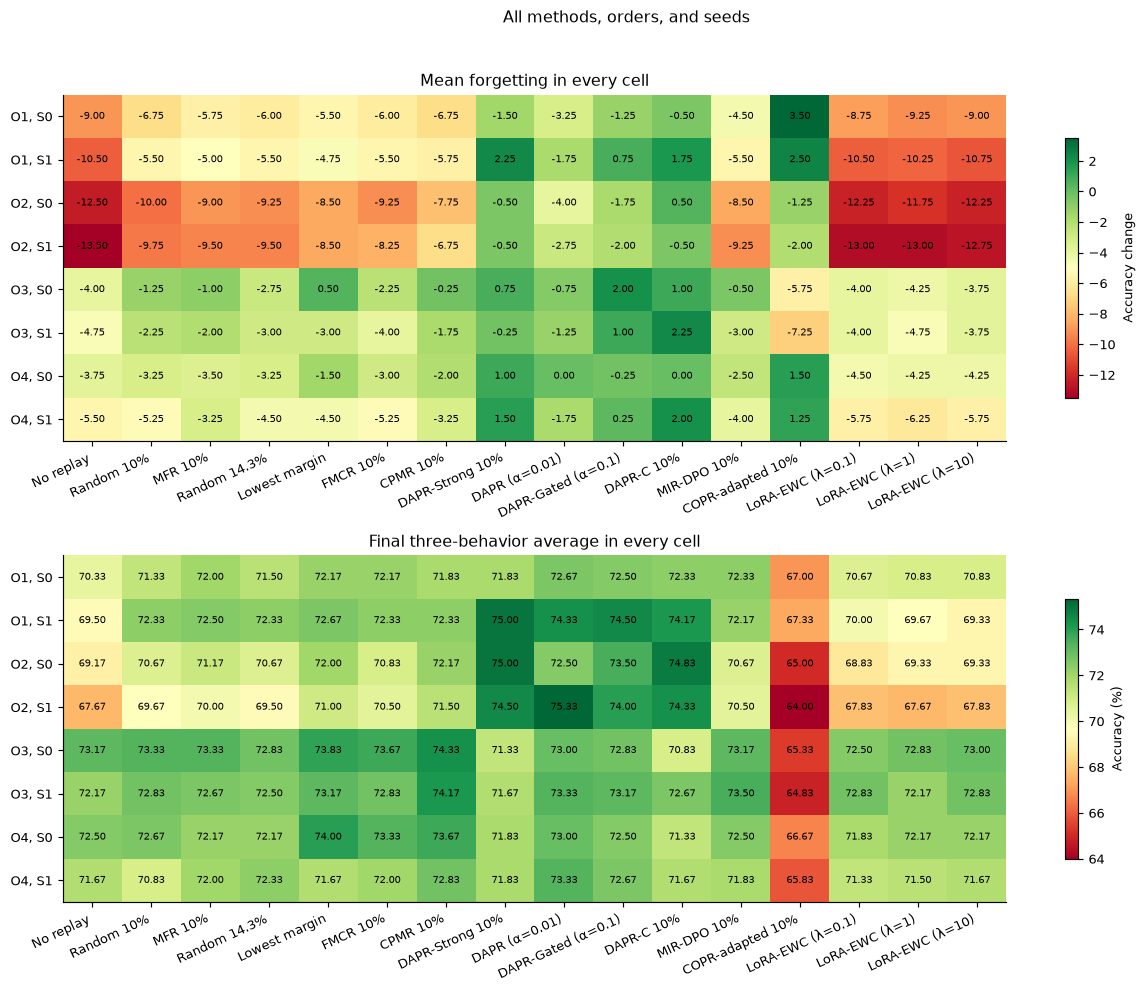

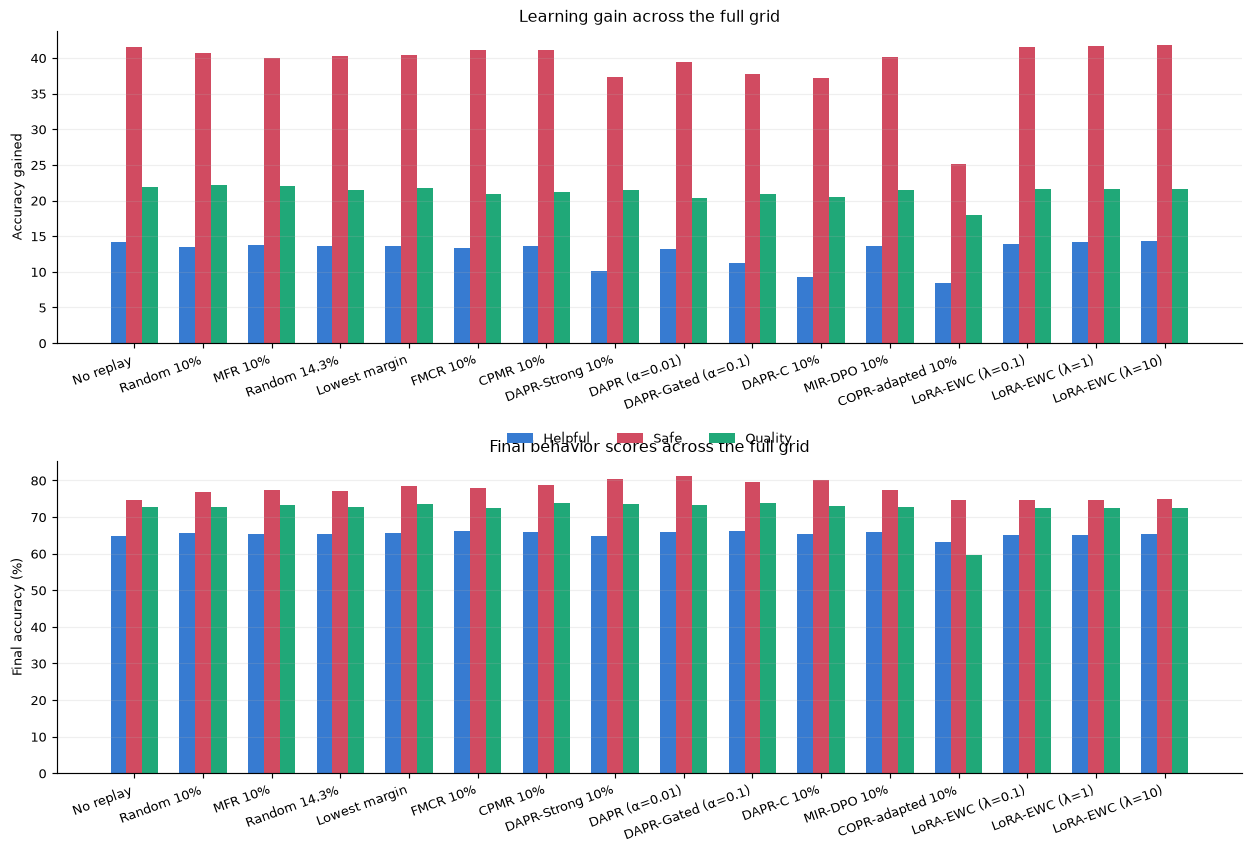

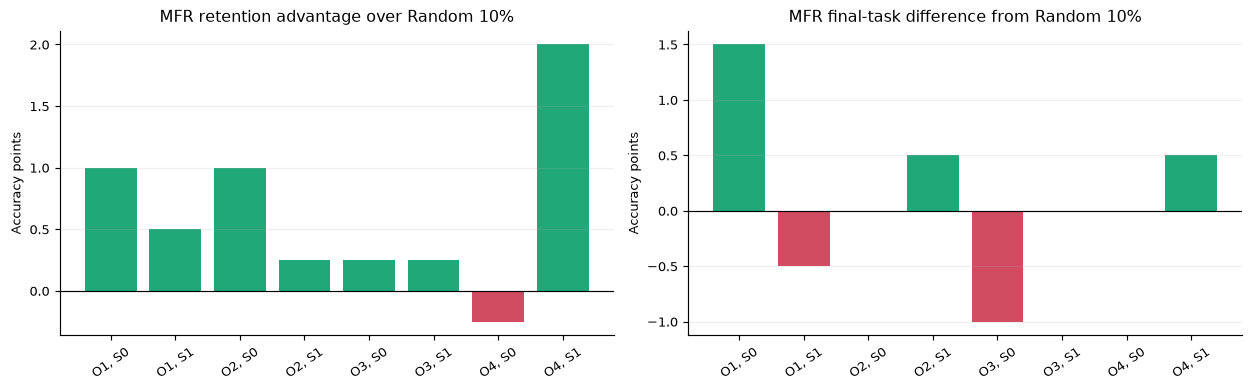

In [ ]:
cell_index=(summary[['order_id','seed']].drop_duplicates()
            .sort_values(['order_id','seed']).reset_index(drop=True))
cell_labels=[f"O{row.order_id}, S{row.seed}" for row in cell_index.itertuples()]

def metric_matrix(metric):
    return (summary.pivot(index=['order_id','seed'],columns='method',values=metric)
            .reindex(pd.MultiIndex.from_frame(cell_index))
            .reindex(columns=METHODS))

def draw_heatmap(ax,data,title,decimals=2):
    image=ax.imshow(data.to_numpy(),aspect='auto',cmap='RdYlGn')
    ax.set_xticks(range(len(METHODS)),[MLABEL[m] for m in METHODS],rotation=25,ha='right')
    ax.set_yticks(range(len(cell_labels)),cell_labels)
    ax.set_title(title)
    for row in range(data.shape[0]):
        for column in range(data.shape[1]):
            ax.text(column,row,f'{data.iloc[row,column]:.{decimals}f}',ha='center',va='center',fontsize=7)
    return image

fig,axes=plt.subplots(2,1,figsize=(max(12,.72*len(METHODS)),9.2))
image=draw_heatmap(axes[0],metric_matrix('old_change'),'Mean forgetting in every cell')
fig.colorbar(image,ax=axes[0],shrink=.75,label='Accuracy change')
image=draw_heatmap(axes[1],metric_matrix('final_average'),'Final three-behavior average in every cell')
fig.colorbar(image,ax=axes[1],shrink=.75,label='Accuracy (%)')
fig.suptitle('All methods, orders, and seeds',y=1.02)
finish(fig,'09_all_cells_heatmaps')

all_learning=[]; all_final=[]
for name,r in records.items():
    part=runs[runs.run_name==name]
    for stage,dataset in enumerate(r['order'],1):
        before=part[(part.stage==stage-1)&(part.eval_set==dataset)]
        after=part[(part.stage==stage)&(part.eval_set==dataset)]
        if len(before) and len(after):
            all_learning.append({'method':r['method'],'dataset':dataset,
                'gain':float(after.iloc[0].accuracy-before.iloc[0].accuracy)})
    last=part[part.stage==len(r['order'])]
    for dataset in DATASETS:
        value=last[last.eval_set==dataset]
        if len(value):
            all_final.append({'method':r['method'],'dataset':dataset,
                              'accuracy':float(value.iloc[0].accuracy)})
learning_means=(pd.DataFrame(all_learning).groupby(['method','dataset']).gain.mean()
                .unstack().reindex(METHODS).reindex(columns=DATASETS))
final_means=(pd.DataFrame(all_final).groupby(['method','dataset']).accuracy.mean()
             .unstack().reindex(METHODS).reindex(columns=DATASETS))

fig,axes=plt.subplots(2,1,figsize=(max(12,.72*len(METHODS)),8.2))
x=np.arange(len(METHODS)); width=.23
for axis,data,title,ylabel in [
    (axes[0],learning_means,'Learning gain across the full grid','Accuracy gained'),
    (axes[1],final_means,'Final behavior scores across the full grid','Final accuracy (%)')]:
    for i,dataset in enumerate(DATASETS):
        axis.bar(x+(i-1)*width,data[dataset],width,label=DLABEL[dataset],color=DCOLOR[dataset])
    axis.set_xticks(x,[MLABEL[m] for m in METHODS],rotation=20,ha='right')
    axis.set_title(title); axis.set_ylabel(ylabel); axis.grid(axis='y',alpha=.2)
axes[1].legend(ncol=3,frameon=False,loc='lower center',bbox_to_anchor=(.5,1.01))
finish(fig,'10_full_grid_learning_and_final_scores')

retention_matrix=metric_matrix('old_change')
final_task_matrix=metric_matrix('final_task')
retention_advantage=retention_matrix['mfr']-retention_matrix['random']
final_task_difference=final_task_matrix['mfr']-final_task_matrix['random']
fig,axes=plt.subplots(1,2,figsize=(12,3.8))
for axis,values,title in [
    (axes[0],retention_advantage,'MFR retention advantage over Random 10%'),
    (axes[1],final_task_difference,'MFR final-task difference from Random 10%')]:
    colors=['#20a878' if value>0 else '#d14b61' if value<0 else '#888888' for value in values]
    axis.bar(cell_labels,values,color=colors)
    axis.axhline(0,color='black',lw=.8); axis.grid(axis='y',alpha=.2)
    axis.set_title(title); axis.set_ylabel('Accuracy points'); axis.tick_params(axis='x',rotation=35)
finish(fig,'11_mfr_vs_random_every_cell')


## 9. Paired uncertainty over all cells

The earlier uncertainty table uses only the selected focus cell. This table instead bootstraps every completed matched order–seed cell and reports how many cells were available. A positive difference favors the target method named in that row. `Interval excludes zero?` is a precise description, not a claim that eight cells with only two seeds settle the question permanently.


Target,Baseline,Cells,Metric,Difference,95% low,95% high,Interval excludes zero?
MFR 10%,No replay,8,Retention,3.06,2.06,4.03,Yes
MFR 10%,No replay,8,Final task,-1.06,-2.25,0.00,No
MFR 10%,No replay,8,Final three-behavior average,1.21,0.46,1.98,Yes
MFR 10%,Random 10%,8,Retention,0.62,0.22,1.09,Yes
MFR 10%,Random 10%,8,Final task,0.12,-0.31,0.62,No
MFR 10%,Random 10%,8,Final three-behavior average,0.27,-0.06,0.62,No
MFR 10%,Random 14.3%,8,Retention,0.59,0.16,1.06,Yes
MFR 10%,Random 14.3%,8,Final task,-0.12,-0.88,0.56,No
MFR 10%,Random 14.3%,8,Final three-behavior average,0.25,0.04,0.44,Yes
MFR 10%,Lowest margin,8,Retention,-0.41,-1.12,0.34,No


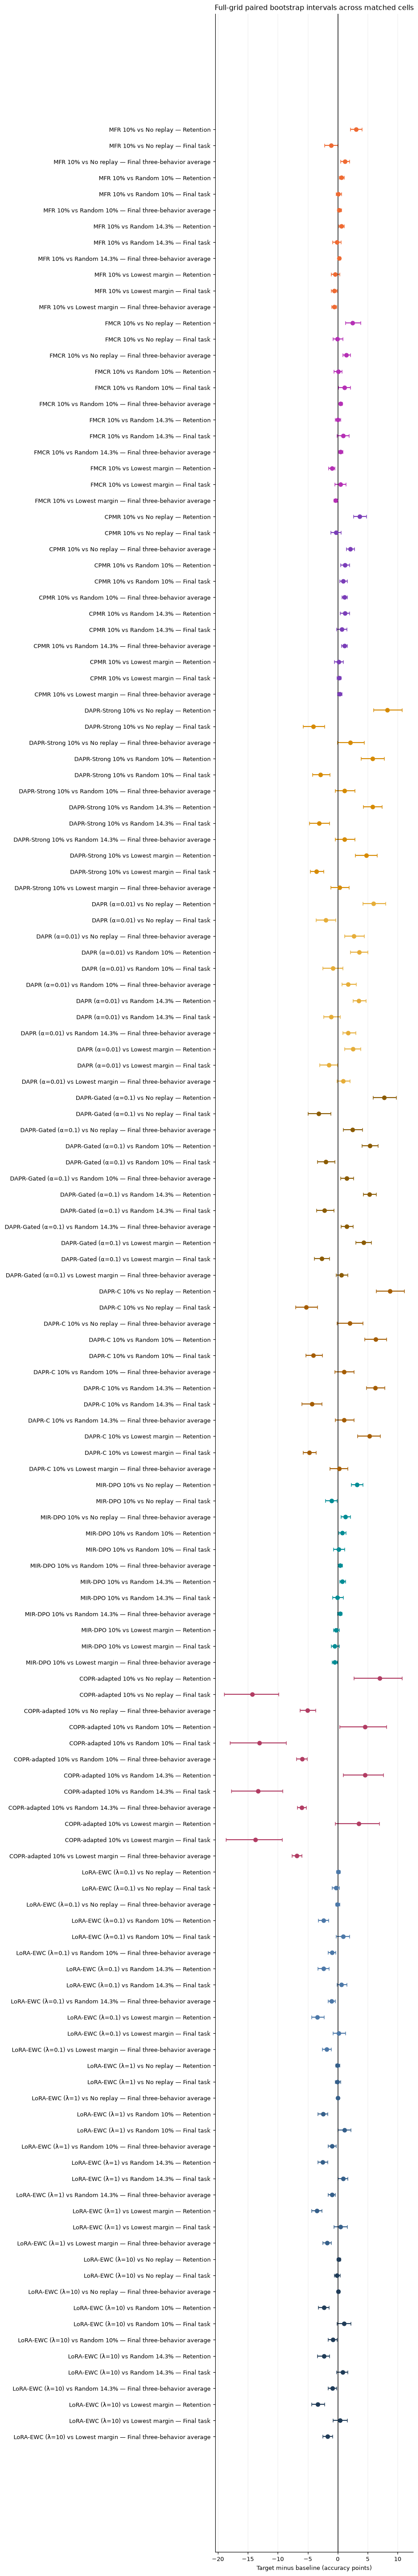

In [ ]:
metric_labels={'old_change':'Retention','final_task':'Final task',
               'final_average':'Final three-behavior average'}
comparison_rows=[]
targets=['mfr']
targets += [method for method in ['fmcr','cpmr','dapr','dapr_weak','dapr_gated',
                                   'dapr_c','mir_dpo','copr_adapted',
                                   'ewc_100','ewc_1000','ewc_10000',
                                   'mfr_balanced','mfr_at_risk']
            if summary[summary.method==method].shape[0]]
baselines=['none','random','random_high','lowest_margin']
for target_index,target in enumerate(targets):
    for baseline_index,baseline in enumerate(baselines):
        for metric_index,metric in enumerate(metric_labels):
            matrix=metric_matrix(metric)
            difference=(matrix[target]-matrix[baseline]).dropna().to_numpy()
            if not len(difference): continue
            rng=np.random.default_rng(700+100*target_index+10*baseline_index+metric_index)
            samples=rng.choice(difference,size=(20000,len(difference)),replace=True).mean(axis=1)
            low,high=np.quantile(samples,[.025,.975])
            comparison_rows.append({'Target':MLABEL[target],'Baseline':MLABEL[baseline],
                'Cells':len(difference),
                'Metric':metric_labels[metric],'Difference':difference.mean(),
                '95% low':low,'95% high':high,
                'Interval excludes zero?':'Yes' if low>0 or high<0 else 'No'})
full_grid_uncertainty=pd.DataFrame(comparison_rows)
show_table(full_grid_uncertainty,'full_grid_uncertainty')

positions=np.arange(len(full_grid_uncertainty))
center=full_grid_uncertainty['Difference'].to_numpy()
low=full_grid_uncertainty['95% low'].to_numpy()
high=full_grid_uncertainty['95% high'].to_numpy()
labels=[f'{row.Target} vs {row.Baseline} — {row.Metric}' for row in full_grid_uncertainty.itertuples()]
fig,ax=plt.subplots(figsize=(9,.37*len(labels)+1.8))
label_to_method={label:method for method,label in MLABEL.items()}
point_colors=[MCOLOR[label_to_method[row.Target]] for row in full_grid_uncertainty.itertuples()]
for y,value,lo,hi,color in zip(positions,center,low,high,point_colors):
    ax.errorbar(value,y,xerr=[[value-lo],[hi-value]],fmt='o',color=color,capsize=3)
ax.axvline(0,color='black',lw=1); ax.grid(axis='x',alpha=.2)
ax.set_yticks(positions,labels); ax.invert_yaxis()
ax.set_xlabel('Target minus baseline (accuracy points)')
ax.set_title('Full-grid paired bootstrap intervals across matched cells')
finish(fig,'12_full_grid_uncertainty')


## 10. Runtime

This averages runtime over every completed order and seed. Scoring time is already included in total runtime and is shown separately to explain the additional cost of margin-based selection.


Method,Runs,Mean total minutes,Mean scoring minutes,Mean replay examples
No replay,8,22.48,0.00,0.0
Random 10%,8,24.28,0.00,444.0
MFR 10%,8,28.28,4.28,444.0
Random 14.3%,8,24.91,0.00,666.0
Lowest margin,8,28.59,4.28,444.0
FMCR 10%,8,29.26,5.29,444.0
CPMR 10%,8,48.75,24.85,444.0
DAPR-Strong 10%,8,29.31,4.28,444.0
DAPR (α=0.01),8,29.13,4.30,444.0
DAPR-Gated (α=0.1),8,29.76,5.02,444.0


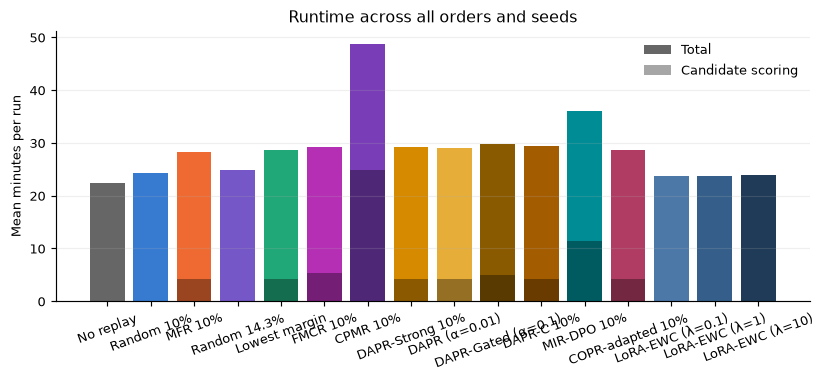

In [ ]:
all_cost=[]
for r in records.values():
    total=0.; scoring=0.; replayed=0
    for stage in range(1,len(r['order'])+1):
        path=stage_folder(r,stage)/'history.csv'
        if not path.exists(): continue
        history=pd.read_csv(path)
        total+=float(history.minutes.max())
        if 'scoring_minutes' in history: scoring+=float(history.scoring_minutes.max())
        if 'n_replay' in history: replayed+=int(history.n_replay.sum())
    all_cost.append({'method':r['method'],'total_minutes':total,
                     'scoring_minutes':scoring,'replay_examples':replayed})
cost_grid=(pd.DataFrame(all_cost).groupby('method').agg(
    Runs=('method','size'),**{'Mean total minutes':('total_minutes','mean'),
    'Mean scoring minutes':('scoring_minutes','mean'),
    'Mean replay examples':('replay_examples','mean')}).reindex(METHODS).reset_index()
    .rename(columns={'method':'Method'}))
cost_grid.Method=cost_grid.Method.map(MLABEL)
show_table(cost_grid,'full_grid_runtime')
fig,ax=plt.subplots(figsize=(8,3.7))
ax.bar(cost_grid.Method,cost_grid['Mean total minutes'],color=[MCOLOR[m] for m in METHODS],label='Total')
ax.bar(cost_grid.Method,cost_grid['Mean scoring minutes'],color='black',alpha=.35,label='Candidate scoring')
ax.set_ylabel('Mean minutes per run'); ax.set_title('Runtime across all orders and seeds')
ax.tick_params(axis='x',rotation=20); ax.grid(axis='y',alpha=.2); ax.legend(frameon=False)
finish(fig,'13_full_grid_runtime')


## 11. LoRA-EWC coefficient selection

LoRA-EWC is a standard no-replay parameter-regularization baseline. It protects LoRA weights that had a large diagonal empirical Fisher value on an earlier behavior. The active settings differ only in the coefficient: 100, 1,000, or 10,000. Smaller diagnostic settings are excluded because a loss-scale audit showed that their weighted penalties were negligible relative to the DPO loss.

This is a development sweep on the same eight cells, not confirmation evidence. Wait until every coefficient has all eight cells. A coefficient is eligible when its mean final-task accuracy is no more than 2 points below Random 10%. Among eligible settings, select the one with the highest final three-behavior average, then freeze it before unseen-seed runs.


In [ ]:
ewc_methods=['ewc_100','ewc_1000','ewc_10000']
ewc_rows=[]
for method in ewc_methods:
    paired=summary[summary.method==method].merge(summary[summary.method=='random'],
        on=['order_id','seed'],suffixes=('_ewc','_random'))
    if paired.empty: continue
    task_difference=(paired.final_task_ewc-paired.final_task_random).mean()
    ewc_rows.append({'Method':MLABEL[method],'Cells':len(paired),
        'Average old-behavior change':paired.old_change_ewc.mean(),
        'Final-task difference vs Random':task_difference,
        'Final three-behavior average':paired.final_average_ewc.mean(),
        'Eligible?':'Yes' if len(paired)==8 and task_difference>=-TOLERANCE else 'No'})
ewc_selection=pd.DataFrame(ewc_rows)
if ewc_selection.empty:
    print('LoRA-EWC has not completed yet. Run all three coefficients in all eight cells.')
else:
    show_table(ewc_selection,'ewc_coefficient_selection')
    complete=ewc_selection[(ewc_selection.Cells==8)&(ewc_selection['Eligible?']=='Yes')]
    if len(complete):
        selected=complete.sort_values('Final three-behavior average',ascending=False).iloc[0]
        print('Selected development coefficient:',selected.Method)
    else:
        print('No coefficient can be selected until all 24 EWC runs finish and at least one setting passes the tolerance.')


Method,Cells,Average old-behavior change,Final-task difference vs Random,Final three-behavior average,Eligible?
LoRA-EWC (λ=0.1),8,-7.84,0.88,70.73,Yes
LoRA-EWC (λ=1),8,-7.97,1.12,70.77,Yes
LoRA-EWC (λ=10),8,-7.78,1.06,70.88,Yes


Selected development coefficient: LoRA-EWC (λ=10)


## 12. Conclusions

The current headline development grid contains 13 completed methods across four orders and two seeds. Tables that compare forgetting are ordered from most forgetting to least forgetting. The current results support these statements:

1. **Catastrophic forgetting is real in this setup.** With no replay, earlier behaviors lose 7.94 accuracy points on average.
2. **Replay usually helps.** The main replay methods reduce average forgetting and improve the final three-behavior average compared with no replay. COPR-adapted is the important exception: it protects old preferences but severely harms new-task learning.
3. **The behaviors do not forget equally.** With no replay, Safety loses 13.25 points, Helpful loses 6.25, and Quality loses 2.50. Safety is the hardest behavior to retain and Quality is the most stable in this setup.
4. **Original MFR improves on equal-budget random replay.** MFR reduces average forgetting from 5.50 to 4.88 points, while slightly improving the final-task score and final three-behavior average. It passes the frozen rule in 7 of 8 order–seed cells.
5. **More random replay is not the explanation.** MFR retains more than Random 14.3% while using one-third fewer replay examples. Its final-average advantage is small but its paired interval excludes zero.
6. **Lowest Margin is the strongest simple replay selector.** It averages -4.47 retention change and 72.56 final average. CPMR is the strongest selection-only extension by point estimate (-4.28 and 72.85), but its small advantage over Lowest Margin is uncertain and costs much more time.
7. **DAPR with α=0.01 is the best observed balance.** It averages -1.94 retention change and the highest final three-behavior average, 73.44. Compared with Lowest Margin, it improves retention by 2.53 points, gives up 1.50 final-task points, and gains 0.87 final-average points. It retains better in 7 of 8 cells and has a higher final average in 6 of 8, but the final-average interval still includes zero.
8. **Anchor strength matters.** DAPR-Strong and DAPR-C nearly remove forgetting but suppress new-task learning. DAPR-Gated is intermediate. The α=0.01 setting gives a better stability–plasticity balance than these stronger constraints.
9. **The paper calls `dapr_weak` simply DAPR.** `dapr_weak` remains the internal code identifier because changing completed run names would damage reproducibility. In writing and figures, DAPR means the selected α=0.01 method; α=0.1 is labeled DAPR-Strong.
10. **The LoRA-EWC comparison is pending.** The active development sweep uses coefficients 100, 1,000, and 10,000. It will enter the comparison only after all three settings complete all eight cells and pass the loss-scale and stability checks.
11. **Joint training is the offline simultaneous-data reference.** Notebook 08 reports 73.20 average validation accuracy over five seeds. On matched Seeds 0 and 1 it reaches 74.00, compared with DAPR's 73.44 four-order average; this descriptive comparison is not a formal paired test.
12. **Order effects partly reflect which behavior is exposed to forgetting.** Order 2 is hardest because fragile Safety is first and must survive two later stages. Orders 3 and 4 look easier partly because stable Quality is early and one of the other behaviors is last. These averages are not a pure causal test of order.
13. **The evidence is still development evidence.** There are only two sequential-training seeds, and the locked test, generation evaluation, error analysis, and human evaluation have not been run.

The safe conclusion is: **targeted replay works, and original MFR reliably beats equal-budget random replay. Present difficulty is a stronger selection signal, but the largest gain comes from changing how selected pairs are optimized: the selected DAPR strength currently gives the best stability–plasticity balance.** DAPR is descriptively close to the offline joint-access reference on matched seeds; the active higher-scale LoRA-EWC comparison is still pending. Keep the locked test set untouched until method selection and unseen-seed confirmation are frozen.
